In [343]:
import torch
import torchvision
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

from pathlib import Path
from torchvision.io import decode_image
from torch.utils.data import DataLoader, Dataset
from torch import nn
from PIL import Image

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)
torch.backends.cudnn.benchmark = True

cuda:0


In [345]:
class ResizeWithPadding:
    def __init__(self, size, fill=256):
        self.size = size
        self.fill = fill  # 256 = white

    def __call__(self, img):
        w, h = img.size
        scale = self.size / max(w, h)
        new_w = int(w * scale)
        new_h = int(h * scale)

        img = transforms.Resize((new_h, new_w))(img)

        pad_w = self.size - new_w
        pad_h = self.size - new_h

        padding = (
            pad_w // 2,                # left
            pad_h // 2,                # top
            pad_w - pad_w // 2,        # right
            pad_h - pad_h // 2,        # bottom
        )

        img = transforms.Pad(padding, fill=self.fill)(img)
        return img

transform = transforms.Compose([
	ResizeWithPadding(128),
	transforms.ToTensor(),
	    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    ),
])

target_transform = transforms.Lambda(lambda y: torch.zeros(
    6, dtype=torch.float).scatter_(dim=0, index=torch.tensor(y), value=1))

In [346]:
class ClimbingHoldDataset(Dataset):
	def __init__(self, annotations_dir, img_dir, transform=None, target_transform=None):
		# for annotations in annotations dir, each line is "label, YOLO format bounding box"
		# we only care about the label for classification
		rows = []
		for fname in os.listdir(annotations_dir):
			annotation_path = os.path.join(annotations_dir, fname)
			label = np.loadtxt(annotation_path, dtype=str)
			if label.ndim == 1:
				label = np.expand_dims(label, axis=0)
			image_fname = os.path.splitext(fname)[0] + '.jpg'
			for row in label:
				class_label = row[0]
				rows.append(np.array([image_fname, class_label]))
		if rows:
			self.img_labels = np.array(rows, dtype=str)
		else:
			self.img_labels = np.empty((0, 2), dtype=str)
	
		self.img_dir = img_dir
		self.transform = transform
		self.target_transform = target_transform

	def __len__(self):
		return len(self.img_labels)
	
	def __getitem__(self, idx):
		img_path = os.path.join(self.img_dir, self.img_labels[idx, 0])
		image = Image.open(img_path).convert("RGB")
		label = int(self.img_labels[idx, 1])
		if self.transform:
			image = self.transform(image)
		if self.target_transform:
			label = self.target_transform(label)
		return image, label

In [347]:
train_dataset_path = Path('Processed_Dataset/train')
train_dataset = ClimbingHoldDataset(
	annotations_dir=os.path.join(train_dataset_path, 'labels'),
	img_dir=os.path.join(train_dataset_path, 'images'),
	transform=transform,
	target_transform=target_transform
)

test_dataset_path = Path('Processed_Dataset/test')
test_dataset = ClimbingHoldDataset(
	annotations_dir=os.path.join(test_dataset_path, 'labels'),
	img_dir=os.path.join(test_dataset_path, 'images'),
	transform=transform,
	target_transform=target_transform
)
print(f"Training dataset size: {len(train_dataset)} samples")
print(f"Test dataset size: {len(test_dataset)} samples")

Training dataset size: 54497 samples
Test dataset size: 6545 samples


In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4,
							   pin_memory=True, persistent_workers=True, prefetch_factor=2)
train_dataiter = iter(train_dataloader)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4,
							  pin_memory=True, persistent_workers=True, prefetch_factor=2)
test_dataiter = iter(test_dataloader)

In [349]:
unique_labels, counts = np.unique(train_dataset.img_labels[:, 1], return_counts=True)
classes = {
	0: 'Crimp',
	1: 'Jug',
	2: 'Pinch',
	3: 'Pocket',
	4: 'Slope',
	5: 'Volume',
}
for label, count in zip(unique_labels, counts):
	class_name = classes.get(int(label), 'Unknown')
	print(f"{class_name} ({label}): {count}")

Crimp (0): 14689
Jug (1): 13848
Pinch (2): 9482
Pocket (3): 4274
Slope (4): 6599
Volume (5): 5605


torch.Size([32, 3, 128, 128])
torch.Size([32, 6])


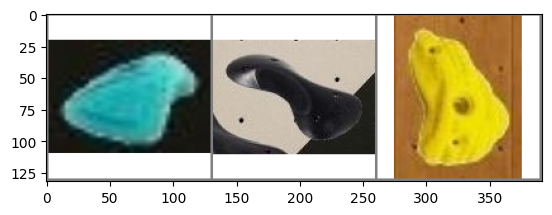

Jug	Slope	Crimp	

In [350]:
images, labels = next(train_dataiter)
print(images.shape)
print(labels.shape)
# Display some images
def imshow(img):
	img = img / 2 + 0.5  # unnormalize
	npimg = img.numpy()
	plt.imshow(np.transpose(npimg, (1, 2, 0)))
	plt.show()

images_to_display = 3
imshow(torchvision.utils.make_grid(images[:images_to_display]))
for j in range(images_to_display):
	for i in range(labels.shape[1]):
		if labels[j][i].item() == 1:
			print(f"{classes[i]}\t", end='')

In [351]:
class Net(nn.Module):
	def __init__(self):
		super().__init__()
		self.linear_relu_stack = nn.Sequential(
			nn.Conv2d(3, 16, 3, padding=1),
			nn.ReLU(),
			nn.MaxPool2d(2, 2),
			nn.Conv2d(16, 32, 3, padding=1),
			nn.ReLU(),
			nn.MaxPool2d(2, 2),
			nn.Flatten(),
			nn.Linear(32 * 32 * 32, 6),
			# nn.ReLU(),
			# nn.Linear(128, 6)
		)

	def forward(self, x):
		x = self.linear_relu_stack(x)
		return x

In [352]:
net = Net()
net.to(device)
print(sum(p.numel() for p in net.parameters()))  # Print number of parameters

201702


In [353]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [ ]:
def train_epoch(net, dataloader, criterion, optimizer):
	net.train()
	for i, data in enumerate(dataloader, 0):
		inputs, labels = data
		inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

		optimizer.zero_grad()

		outputs = net(inputs)
		loss = criterion(outputs, torch.max(labels, 1)[1])
		loss.backward()
		optimizer.step()

def test_model(net, dataloader):
	net.eval()
	correct = 0
	total = 0
	with torch.no_grad():
		for data in dataloader:
			images, labels = data
			images, labels = images.to(device), labels.to(device)
			outputs = net(images)
			_, predicted = torch.max(outputs.data, 1)
			_, labels_max = torch.max(labels.data, 1)
			total += labels.size(0)
			correct += (predicted == labels_max).sum().item()
	accuracy = 100 * correct / total
	print(f'Accuracy of the network on the test images: {accuracy:.2f}%')
	return accuracy

In [ ]:
epochs = 5
epoch_accuracy = np.zeros((epochs+1, 1)) # +1 for baseline

print('Baseline evaluation on training set:')
epoch_accuracy[0] = test_model(net, test_dataloader)

Baseline evaluation on training set:
Accuracy of the network on the test images: 11.80%


In [ ]:
print('------------')
for epoch in range(epochs):  # loop over the dataset multiple times
	print(f'Epoch {epoch + 1}')
	train_epoch(net, train_dataloader, criterion, optimizer)
	print('Testing on training set:')
	epoch_accuracy[epoch+1] = test_model(net, test_dataloader)
	print('------------')
print('Finished Training')

------------
Epoch 1
Testing on training set:
Accuracy of the network on the test images: 54.94%
------------
Epoch 2
Testing on training set:
Accuracy of the network on the test images: 63.51%
------------
Epoch 3
Testing on training set:
Accuracy of the network on the test images: 67.94%
------------
Epoch 4
Testing on training set:
Accuracy of the network on the test images: 70.36%
------------
Epoch 5
Testing on training set:
Accuracy of the network on the test images: 73.83%
------------
Finished Training


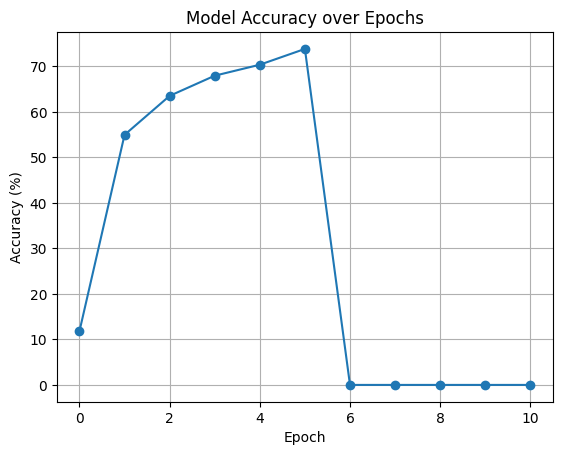

In [357]:
# Plot accuracy over epochs
plt.plot(range(epochs+1), epoch_accuracy, marker='o')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid()
plt.show()

In [358]:
model_path = Path('climbing_hold_classifier.pth')
torch.save(net.state_dict(), model_path)

In [359]:
net = Net()
net.load_state_dict(torch.load(model_path))
net.to(device)
net.eval()

Net(
  (linear_relu_stack): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=32768, out_features=6, bias=True)
  )
)

In [360]:
test_dataiter = iter(test_dataloader)

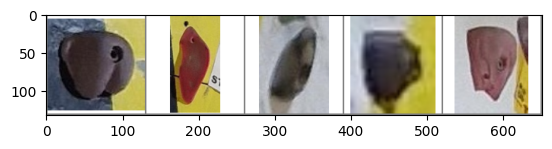

Jug	Pinch	Crimp	Crimp	Jug	

In [376]:
images, labels = next(test_dataiter)

images_to_display = 5
imshow(torchvision.utils.make_grid(images[:images_to_display]))
for j in range(images_to_display):
	for i in range(labels.shape[1]):
		if labels[j][i].item() == 1:
			print(f"{classes[i]}\t", end='')

In [377]:
outputs = net(images.to(device))
_, predicted = torch.max(outputs, 1)
predicted = predicted.cpu()
labels = labels.cpu()
probs = torch.softmax(outputs, dim=1).cpu()
for j in range(min(images_to_display, labels.size(0))):
    actual_idx = labels.argmax(dim=1)[j].item()
    pred_idx = predicted[j].item()
    conf = probs[j, pred_idx].item()
    print(f"Actual: {classes[actual_idx]:10s}  Predicted: {classes[pred_idx]:10s}  Conf: {100*conf:.2f}%")


Actual: Jug         Predicted: Slope       Conf: 43.97%
Actual: Pinch       Predicted: Crimp       Conf: 90.64%
Actual: Crimp       Predicted: Crimp       Conf: 35.07%
Actual: Crimp       Predicted: Crimp       Conf: 97.33%
Actual: Jug         Predicted: Jug         Conf: 45.50%


In [ ]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = net(images)
        _, predictions = torch.max(outputs, 1)

        predictions = predictions.cpu()
        labels = labels.cpu()

        for label, pred in zip(labels, predictions):
            label = label.argmax().item()
            pred = pred.item()

            if pred == label:
                correct_pred[label] += 1
            total_pred[label] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for {classes[classname]}: {accuracy:.1f} %')

Accuracy for Crimp: 83.5 %
Accuracy for Jug: 75.1 %
Accuracy for Pinch: 50.0 %
Accuracy for Pocket: 72.3 %
Accuracy for Slope: 77.3 %
Accuracy for Volume: 85.9 %
